# Importing Libraries

In [1]:
# Core Data Manipulation
import numpy as np
import pandas as pd

# Machine Learning & Clustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# ata Visualization
import matplotlib.pyplot as plt

# Geospatial Analysis
import geopandas as gpd
from keplergl import KeplerGl


# Loading DF

In [2]:
pre_norm_df_final = pd.read_csv('..\\Data\\display_rdy_STREET_4.csv', low_memory=False)
norm_df = pd.read_csv('..\\Data\\norm_STREET_5.csv', low_memory=False)
nyc_map = gpd.read_file("..\\Data\\new-york-city-boroughs.geojson.txt")
streets_projected = gpd.read_file("..\\Data\\nyc_clustered_streets.gpkg")

# Clustering Hierarchical

In [3]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:\n", labels)
    print("===================")
    print("Cluster Counts:\n", labels.value_counts())


In [4]:
# Drop incident zip column
Features = norm_df.drop("Street_Name", axis=1)

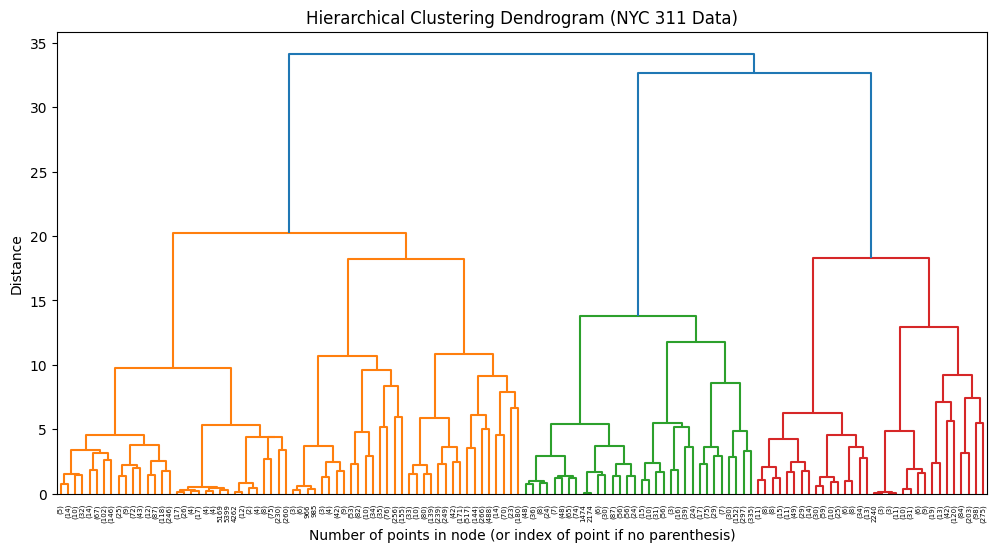

In [5]:
# Fitting the model 
agg = AgglomerativeClustering(
    distance_threshold=0,
    n_clusters=None,
    compute_distances=True
)
agg.fit(Features)

# Dendrogram plot func
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


# Plot the Dendrogram
plt.figure(figsize=(12, 6))
plot_dendrogram(agg, truncate_mode='level', p=6) # p is rendreing limit
plt.title("Hierarchical Clustering Dendrogram (NYC 311 Data)")
plt.xlabel("Number of points in node (or index of point if no parenthesis)")
plt.ylabel("Distance")
plt.show()


## Silhouette Score

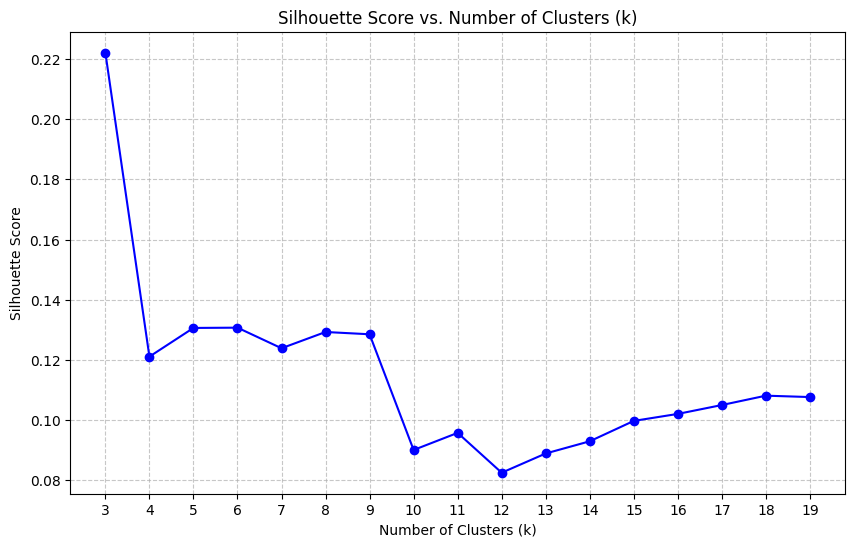

In [6]:
score_lst = []
k_range = range(3, 20) # Define the range once to keep it consistent

for k in k_range:
    # Get labels
    clustering = AgglomerativeClustering(n_clusters=k).fit(Features)
    labels = clustering.fit_predict(Features)
    pre_norm_df_final["Cluster"] = labels

    # Calculate the Silhouette Score
    score = silhouette_score(Features, labels)
    score_lst.append(score)

# Create the x-axis list (number of clusters)
k_lst = list(k_range)    

# --- Make the plot ---
plt.figure(figsize=(10, 6)) # Set the figure size
plt.plot(k_lst, score_lst, marker='o', linestyle='-', color='b') # Added points 'o' for visibility

# Add labels and title
plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

# Formatting to make it look nice
plt.xticks(k_lst) # Shows every 'k' value on the x-axis
plt.grid(True, linestyle='--', alpha=0.7) # Adds a grid

# Display the plot
plt.show()

## Running Clustering for 9 clusters

In [7]:
# Get labels
final_clustering = AgglomerativeClustering(n_clusters = 9)
labels = final_clustering.fit_predict(Features)
pre_norm_df_final['Cluster'] = labels
output(labels)

The labels:
 0       5
1       4
2       0
3       1
4       0
       ..
8063    5
8064    5
8065    4
8066    0
8067    1
Length: 8068, dtype: int64
Cluster Counts:
 0    2665
1    1668
5     942
3     854
2     770
6     571
4     330
8     194
7      74
Name: count, dtype: int64


In [8]:
# Define the outlier clusters we want to push to the end
vc = pre_norm_df_final['Cluster'].value_counts()
outlier_clusters = singleton_labels = vc[vc == 1].index.tolist()

# Get a list of all current clusters in the dataframe, sorted numerically
current_clusters = sorted(pre_norm_df_final['Cluster'].dropna().unique())

# Separate the "main" clusters from the "outlier" clusters
main_clusters = [c for c in current_clusters if c not in outlier_clusters]
outliers_present = [c for c in outlier_clusters if c in current_clusters]

# Create a new ordered list: Main clusters first, followed by outliers at the end
new_cluster_order = main_clusters + outliers_present

# Create a mapping dictionary {old_id: new_id}
# This automatically assigns 0, 1, 2... etc.
# THe main clusters will become 0 to 10, and the outliers will become 11, 12, 13, 14.
cluster_mapping = {old_id: new_id for new_id, old_id in enumerate(new_cluster_order)}

# Let's print the mapping so we can verify it worked exactly as you wanted
print("Here is how the clusters are being renumbered:")
for old, new in cluster_mapping.items():
    print(f"Old Cluster {old} --> New Cluster {new}")

# Apply the mapping to overwrite the old numbers
pre_norm_df_final['Cluster'] = pre_norm_df_final['Cluster'].map(cluster_mapping)

Here is how the clusters are being renumbered:
Old Cluster 0 --> New Cluster 0
Old Cluster 1 --> New Cluster 1
Old Cluster 2 --> New Cluster 2
Old Cluster 3 --> New Cluster 3
Old Cluster 4 --> New Cluster 4
Old Cluster 5 --> New Cluster 5
Old Cluster 6 --> New Cluster 6
Old Cluster 7 --> New Cluster 7
Old Cluster 8 --> New Cluster 8


In [9]:
# Extract the centroids from the fitted model
features_with_labels = Features.copy()
features_with_labels['Cluster'] = labels

# Calculate the manual "centroids" (the mathematical average of each cluster)
hierarchical_centroids = features_with_labels.groupby('Cluster').mean()
# 1. Calculate the Global Means across your entire dataset
global_means = Features.mean()

def analyze_relative_personas(centroid_dataframe, global_averages, top_n=3):
    """
    Identifies distinct personas by finding features that are significantly
    higher than the global baseline (Relative Importance / Lift).
    """
    print(f"--- Top {top_n} Unique Defining Features per Cluster ---\n")
    
    # Calculate the relative importance (Cluster Mean / Global Mean)
    # Adding a tiny number (1e-9) prevents division by zero errors
    relative_importance = centroid_dataframe / (global_averages + 1e-9)
    
    for cluster_id in centroid_dataframe.index:
        
        # Isolate the relative multipliers for this cluster
        cluster_multipliers = relative_importance.loc[cluster_id]
        
        # Sort by the highest multiplier to find what makes them unique
        top_features = cluster_multipliers.sort_values(ascending=False).head(top_n)
        
        print(f"Cluster {cluster_id} Persona:")
        for feature, multiplier in top_features.items():
            
            # Grab the actual absolute value just for context
            actual_val = centroid_dataframe.loc[cluster_id, feature]
            
            # Print the feature, how many times the average it is, and the raw value
            print(f"  * {feature}: {multiplier:.1f}x the global average (Raw value: {actual_val:.4f})")
            
        print("-" * 50)

# Run the function
analyze_relative_personas(hierarchical_centroids, global_means, top_n=4)

--- Top 4 Unique Defining Features per Cluster ---

Cluster 0 Persona:
  * Public_Spaces_and_Outdoors_Pct: 1.8x the global average (Raw value: 0.0266)
  * Public_Order_and_Police_Pct: 1.7x the global average (Raw value: 0.0543)
  * Institutions,_Health_and_Services_Pct: 1.6x the global average (Raw value: 0.0021)
  * Other/Misc_CType_Pct: 1.5x the global average (Raw value: 0.0600)
--------------------------------------------------
Cluster 1 Persona:
  * Vehicles_and_Parking_Pct: 2.2x the global average (Raw value: 0.6080)
  * Street_and_Transportation_Pct: 1.4x the global average (Raw value: 0.8293)
  * Weekend_Ratio: 1.0x the global average (Raw value: 0.2494)
  * Total_Complaints: 0.9x the global average (Raw value: 0.0863)
--------------------------------------------------
Cluster 2 Persona:
  * Taxi_and_For-Hire_Vehicles_Pct: 3.6x the global average (Raw value: 0.0126)
  * Trees_and_Parks_Pct: 3.1x the global average (Raw value: 0.1536)
  * Sanitation_and_Trash_Pct: 2.9x the globa

## Visualizations ( Maps )

In [ ]:
# ============================================================
# STEP 1 — Filter streets to those in our data
# ============================================================

streets_to_plot = streets_projected[
    streets_projected['full_street_name'].isin(pre_norm_df_final['Street_Name'])
][['full_street_name', 'geometry']].copy()

streets_to_plot = streets_to_plot.dissolve(by='full_street_name').reset_index()

# ============================================================
# STEP 2 — Merge cluster info
# ============================================================

streets_to_plot = streets_to_plot.merge(
    pre_norm_df_final[['Street_Name', 'Cluster']],
    left_on='full_street_name',
    right_on='Street_Name',
    how='left'
)

streets_to_plot['Cluster'] = 'Cluster ' + streets_to_plot['Cluster'].astype(str)

# ============================================================
# STEP 3 — Reproject to 4326
# ============================================================

streets_to_plot = streets_to_plot.to_crs(epsg=4326)

print(f"Rendering {len(streets_to_plot):,} streets across {streets_to_plot['Cluster'].nunique()} clusters...")

# ============================================================
# STEP 4 — Build NYC outline from nyc_map (zip code polygons)
# ============================================================

boroughs = nyc_map[['geometry']].copy()  
boroughs['region'] = 'NYC'
boroughs = boroughs.dissolve(by='region').reset_index()  # merge all zips into one outline
boroughs = boroughs.to_crs(epsg=4326)

# ============================================================
# STEP 5 — Kepler.gl config
# ============================================================

kepler_config = {
    'version': 'v1',
    'config': {
        'visState': {
            'layers': [
                {
                    'type': 'geojson',
                    'config': {
                        'dataId': 'NYC Boroughs',
                        'label': 'NYC Boroughs',
                        'isVisible': True,
                        'visConfig': {
                            'opacity':       0.0,    # no fill, outline only
                            'strokeOpacity': 0.9,
                            'thickness':     1.5,
                            'stroked':       True,
                            'filled':        False,
                            'strokeColor':   [0, 0, 0],
                        },
                    },
                },
                {
                    'type': 'geojson',
                    'config': {
                        'dataId': 'NYC Streets by Cluster',
                        'label': 'NYC Streets by Cluster',
                        'isVisible': True,
                        'visConfig': {
                            'opacity':        0.85,
                            'strokeOpacity':  0.8,
                            'thickness':      0.5,
                            'stroked':        True,
                            'filled':         True,
                            'enable3d':       False,
                            'colorRange': {
                                'name':     'ColorBrewer Set1-9',
                                'type':     'qualitative',
                                'category': 'ColorBrewer',
                                'colors':   [
                                    '#e41a1c','#377eb8','#4daf4a',
                                    '#984ea3','#ff7f00','#ffff33',
                                    '#a65628','#f781bf','#999999'
                                ]
                            },
                        },
                    },
                    'visualChannels': {
                        'colorField': {
                            'name': 'Cluster',
                            'type': 'string'
                        },
                        'colorScale': 'ordinal',
                    }
                },
            ]
        },
        'mapState': {
            'latitude':  40.73,
            'longitude': -73.93,
            'zoom':      10
        },
        'mapStyle': {
            'styleType': 'dark',
            'visibleLayerGroups': {
                'label':    True,
                'road':     True,
                'border':   True,
                'building': False,
                'water':    True,
                'land':     True,
            }
        }
    }
}

# ============================================================
# STEP 6 — Render
# ============================================================

kepler_map = KeplerGl(height=750, config=kepler_config)

# Outline added first so it renders underneath
kepler_map.add_data(
    data=boroughs[['region', 'geometry']],
    name='NYC Boroughs'
)

kepler_map.add_data(
    data=streets_to_plot[['full_street_name', 'Cluster', 'geometry']],
    name='NYC Streets by Cluster'
)

kepler_map